# Deep Learning 1 — O que uma rede neural calcula

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/ml-dl/dl1_o_que_a_rede_calcula.ipynb)

Nesta aula vamos olhar para uma rede neural como ela realmente é: **uma função matemática**. Sem mistério:
somas ponderadas, multiplicações de matrizes e algumas funções não lineares.

**Roteiro**

1. O exemplo da semana: imagens de dígitos escritos à mão (MNIST)
2. O neurônio: soma ponderada + viés
3. A camada: uma multiplicação de matrizes, $y = Wx + b$
4. *Forward pass* (passagem para frente) à mão e no PyTorch
5. Uma rede de verdade aplicada ao MNIST
6. Por que precisamos de funções de ativação
7. O Teorema da Aproximação Universal

> Este é o primeiro de quatro notebooks do bloco de Deep Learning. Todos usam o MNIST, e cada um parte de
> onde o anterior parou.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms


AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

torch.manual_seed(42)
np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)
torch.__version__

'2.14.1'

##  MNIST dataset

O MNIST é o "Olá, mundo!" do Deep Learning: 60 mil imagens de treino e 10 mil de teste, cada uma com um
dígito de 0 a 9 escrito à mão, em tons de cinza, com 28 × 28 pixels. A tarefa é **classificar** a imagem no
dígito correto (10 classes).

O `torchvision` baixa o dataset na primeira vez (≈ 60 MB) e guarda na pasta `data/`.
`transforms.ToTensor()` converte cada imagem em um **tensor** do PyTorch com valores entre 0 e 1.

In [ ]:
mnist = datasets.MNIST(root="data", 
                       train=True, 
                       download=True, 
                       transform=transforms.ToTensor()
                       )

imagem, rotulo = mnist[0]
print(f"{len(mnist)} imagens de treino")
print(f"formato de uma imagem: {tuple(imagem.shape)}  (canal, altura, largura)")
print(f"valores entre {imagem.min():.0f} e {imagem.max():.0f}; rótulo = {rotulo}")

60000 imagens de treino
formato de uma imagem: (1, 28, 28)  (canal, altura, largura)
valores entre 0 e 1; rótulo = 5


In [ ]:
imagem.

torch.Size([1, 28, 28])

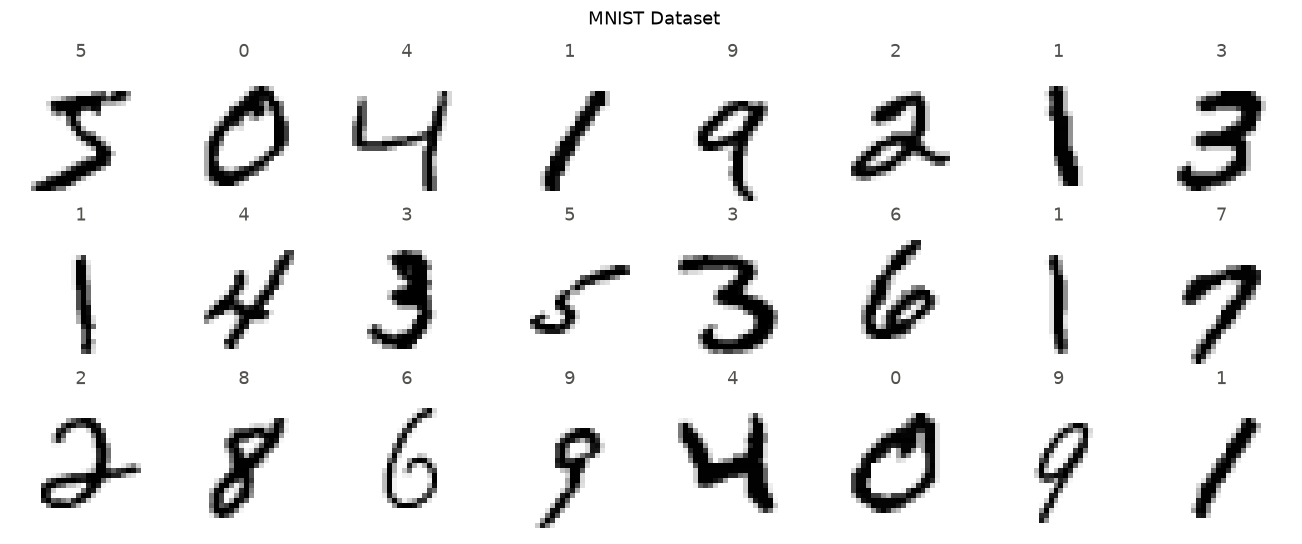

In [7]:
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for ax, i in zip(axes.flat, range(24)):
    img, y = mnist[i]
    ax.imshow(img[0], cmap="gray_r")
    ax.set_title(str(y), color=TINTA)
    ax.axis("off")
plt.suptitle(" MNIST Dataset")
plt.tight_layout()
plt.show()

### Uma imagem nada mais é do que apenas uma sequencia de números

A rede que vamos construir (um **MLP**, *Multi-Layer Perceptron*) recebe um **vetor**. Por isso
"achatamos" a imagem: as 28 linhas de 28 pixels viram um vetor de **784 números**. Isso é exatamente o que
faz a camada `nn.Flatten()`.

In [12]:
imagem.flatten().unsqueeze(0).shape

torch.Size([1, 784])

(1, 28, 28) > (1, 784)


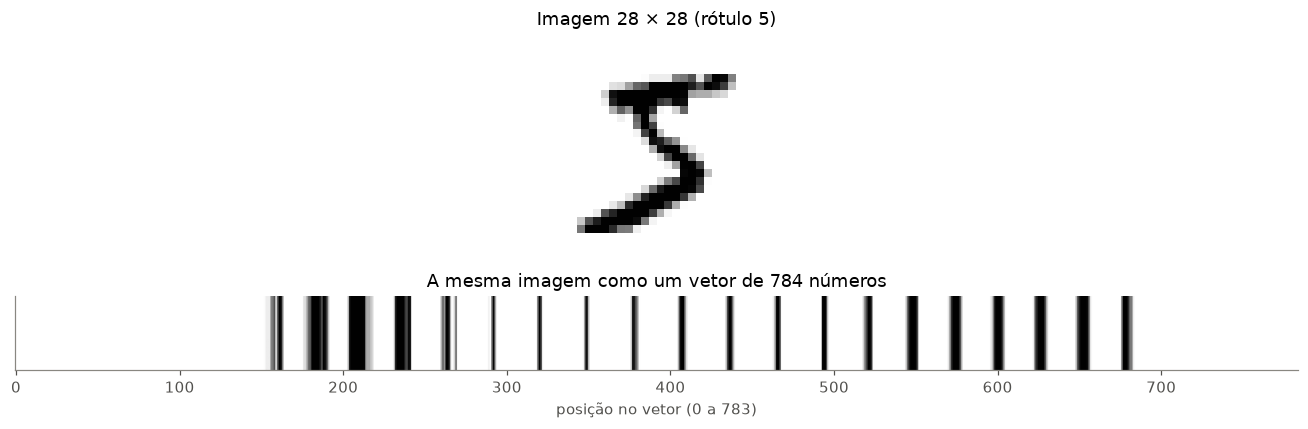

In [18]:
vetor = nn.Flatten()(imagem.unsqueeze(0))   # pyTorch espera um batch de imagens
print(f"{tuple(imagem.shape)} > {tuple(vetor.shape)}")

fig, axes = plt.subplots(2, 1, figsize=(12, 4), height_ratios=[3, 1])
axes[0].imshow(imagem[0], cmap="gray_r")
axes[0].set_title(f"Imagem 28 × 28 (rótulo {rotulo})")
axes[0].axis("off")
axes[1].imshow(vetor, cmap="gray_r", aspect="auto")
axes[1].set(yticks=[], xlabel="posição no vetor (0 a 783)", title="A mesma imagem como um vetor de 784 números")
axes[1].grid(False)
plt.tight_layout()
plt.show()

## Neurônio

O neuronio pode ser visto como uma soma ponderada entre os pesos e o viés. Como vimos em nossa aula teórica. 

Um neurônio artificial recebe entradas $x_1, x_2, \dots, x_n$, multiplica cada uma por um **peso** $w_i$,
soma tudo e adiciona um **viés** (*bias*) $b$:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

Os pesos dizem **o quanto** cada entrada importa (e se ela empurra o resultado para cima ou para baixo).
O viés desloca o resultado. Pesos e viés são os **parâmetros** que a rede vai aprender.

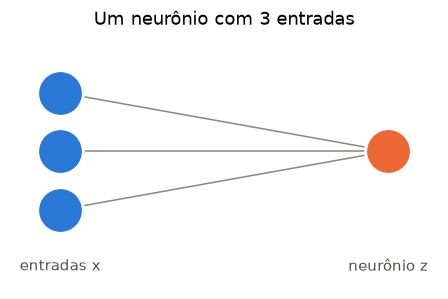

In [19]:
def desenha_rede(camadas, ax, rotulos=None, titulo=""):
    """Desenha uma rede totalmente conectada: camadas = nº de neurônios por camada."""
    xs = np.linspace(0, 1, len(camadas))
    pos = []
    for x, n in zip(xs, camadas):
        ys = np.linspace(0.5 - 0.15 * (n - 1), 0.5 + 0.15 * (n - 1), n)
        pos.append([(x, y) for y in ys])
    for a, b in zip(pos[:-1], pos[1:]):
        for (x0, y0) in a:
            for (x1, y1) in b:
                ax.plot([x0, x1], [y0, y1], color=CINZA, lw=1, zorder=1)
    cores = [AZUL] + [VERDE] * (len(camadas) - 2) + [LARANJA]
    for camada, cor in zip(pos, cores):
        for (x, y) in camada:
            ax.scatter(x, y, s=900, color=cor, zorder=2, edgecolor="white", lw=2)
    if rotulos:
        for x, r in zip(xs, rotulos):
            ax.text(x, -0.05, r, ha="center", va="top", color=TINTA)
    ax.set(xlim=(-0.15, 1.15), ylim=(-0.2, 1.1), title=titulo)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(5, 3))
desenha_rede([3, 1], ax, ["entradas x", "neurônio z"], "Um neurônio com 3 entradas")
plt.show()

In [20]:
x = np.array([0.9, 0.3, 0.6])     # 3 entradas (por exemplo, 3 pixels ou 3 features)
w = np.array([0.4, -0.6, 0.9])    # 1 peso por entrada
b = 0.1                           # viés

for i in range(3):
    print(f"w{i + 1}·x{i + 1} = {w[i]:+.1f} × {x[i]:.1f} = {w[i] * x[i]:+.2f}")

## a magia acontece aqui! 
# veja como a multiplicacao é realizada em numpy, atraves do @ (multiplicação matricial)
z = w @ x + b

print(f"\nz = soma + b = {(w * x).sum():+.2f} {b:+.1f} = {z:+.2f}")

w1·x1 = +0.4 × 0.9 = +0.36
w2·x2 = -0.6 × 0.3 = -0.18
w3·x3 = +0.9 × 0.6 = +0.54

z = soma + b = +0.72 +0.1 = +0.82


## Ampliando o número de neurônios

Uma **camada** é um grupo de neurônios que recebem as mesmas entradas, cada um com seus próprios pesos.
Empilhando os vetores de pesos como linhas de uma matriz $W$, a camada inteira vira uma única operação:

$$\mathbf{y} = W\mathbf{x} + \mathbf{b}$$

Com 3 entradas e 2 neurônios, $W$ tem formato $2 \times 3$ (uma linha por neurônio) e $\mathbf{b}$ tem 2
valores. É por isso que GPUs são tão boas para Deep Learning: elas são máquinas de multiplicar matrizes.

In [21]:
W = np.array([[0.4, -0.6, 0.9],    # pesos do neurônio 1 (o mesmo do exemplo acima)
              [-0.3, 0.2, 0.5]])   # pesos do neurônio 2
b = np.array([0.1, -0.2])

y = W @ x + b
print(f"W: {W.shape}, x: {x.shape}, b: {b.shape}  →  y: {y.shape}")
print(f"y = {y}")

W: (2, 3), x: (3,), b: (2,)  →  y: (2,)
y = [ 0.82 -0.11]


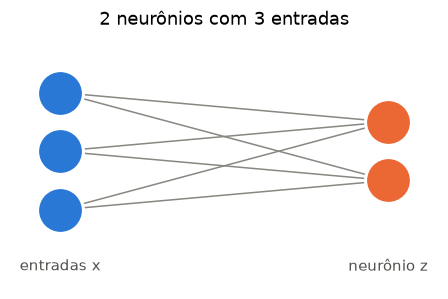

In [24]:
fig, ax = plt.subplots(figsize=(5, 3))
desenha_rede([3, 2], ax, ["entradas x", "neurônio z"], "2 neurônios com 3 entradas")
plt.show()

No PyTorch, uma camada assim é um `nn.Linear(entradas, saídas)`. Para o MNIST, uma camada de 784 entradas
(os pixels) para 128 neurônios tem uma matriz de pesos $128 \times 784$:

In [8]:
camada = nn.Linear(784, 128)
print(f"pesos W: {tuple(camada.weight.shape)}   viés b: {tuple(camada.bias.shape)}")
print(f"parâmetros: {camada.weight.numel():,} pesos + {camada.bias.numel()} vieses = {sum(p.numel() for p in camada.parameters()):,}")

pesos W: (128, 784)   viés b: (128,)
parâmetros: 100,352 pesos + 128 vieses = 100,480


## 4. *Forward pass*

Empilhando camadas, temos um **MLP**. O *forward pass* é simplesmente calcular a saída, camada por camada.
Vamos fazer à mão uma rede pequena com 3 entradas, 2 neurônios escondidos e 1 saída:

$$\mathbf{h} = \text{ReLU}(W_1\mathbf{x} + \mathbf{b}_1) \qquad \hat{y} = W_2\mathbf{h} + b_2$$

A $\text{ReLU}(z) = \max(0, z)$ é uma **função de ativação**: zera os valores negativos. Na seção 6 veremos
por que ela é indispensável.

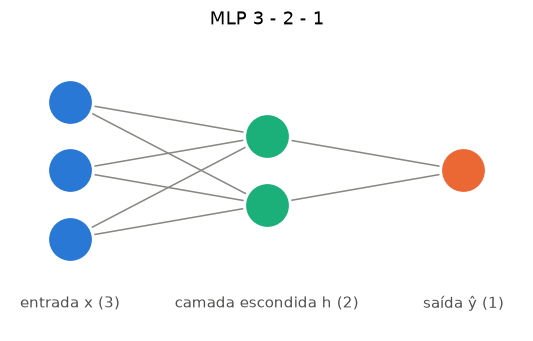

In [25]:
fig, ax = plt.subplots(figsize=(6, 3.5))
desenha_rede([3, 2, 1], ax, ["entrada x (3)", "camada escondida h (2)", "saída ŷ (1)"], "MLP 3 - 2 - 1")
plt.show()

In [26]:
x = np.array([0.9, 0.3, 0.6])
W1 = np.array([[0.4, -0.6, 0.9],
               [-0.3, 0.2, 0.5]])
b1 = np.array([0.1, -0.2])
W2 = np.array([[1.5, -2.0]])
b2 = np.array([0.3])

z1 = W1 @ x + b1
h = np.maximum(0, z1)          # ReLU
y_hat = W2 @ h + b2

print(f"1) z1 = W1·x + b1      = {z1}")
print(f"2) h  = ReLU(z1)        = {h}")
print(f"3) ŷ  = W2·h + b2       = {y_hat}")

1) z1 = W1·x + b1      = [ 0.82 -0.11]
2) h  = ReLU(z1)        = [0.82 0.  ]
3) ŷ  = W2·h + b2       = [1.53]


Repare no passo 2: o segundo neurônio deu um valor negativo e a ReLU o **zerou**. Para esta entrada, ele
simplesmente não contribui para a saída: $\hat{y} = 1{,}5 \times 0{,}82 - 2{,}0 \times 0 + 0{,}3 = 1{,}53$.

Agora a **mesma** rede no PyTorch. Copiamos os pesos acima para dentro de dois `nn.Linear` e conferimos se o
resultado é idêntico. Ele precisa ser: o PyTorch não faz nada além dessas contas.

In [ ]:
rede = nn.Sequential(nn.Linear(3, 2), 
                     nn.ReLU(), 
                     nn.Linear(2, 1)
                     )

with torch.no_grad():   # o no_grad serve apenas para computar o forward pass
    rede[0].weight.copy_(torch.tensor(W1)); rede[0].bias.copy_(torch.tensor(b1))
    rede[2].weight.copy_(torch.tensor(W2)); rede[2].bias.copy_(torch.tensor(b2))

saida_torch = rede(torch.tensor(x, 
                                dtype=torch.float32)
                                )

print(f"à mão:   {y_hat[0]:.6f}")
print(f"PyTorch: {saida_torch.item():.6f}")

à mão:   1.530000
PyTorch: 1.530000


In [37]:
rede.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=3, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)>

## Uma MLP para o MNIST

A mesma ideia, maior: 784 pixels → 128 neurônios escondidos → **10 saídas** (uma para cada dígito).

As 10 saídas são chamadas de ***logits***: números quaisquer, positivos ou negativos. Para transformá-los em
probabilidades que somam 1, usamos a função **softmax**:

$$p_k = \frac{e^{z_k}}{\sum_{j=0}^{9} e^{z_j}}$$

Usamos a softmax aqui, ao invés de sigmoid, porque com softmax, a soma da probabilidade de todos os elementos é igual a 1. Com sigmoid, cada elemento possuiria uma probabilidade também entre [0,1] mas sua soma pode vir a ser maior do que 1. Limitando essa de probabilidades a 1, classificamos o resultado de acordo com a maior probabilidade entre os 10 números possíveis de saída [0,9]


O dígito previsto é o de maior probabilidade.

In [36]:
modelo = nn.Sequential(
    nn.Flatten(),           # (lote, 1, 28, 28) para (lote, 784)
    nn.Linear(784, 128),    # camada escondida
    nn.ReLU(),              # ativação
    nn.Linear(128, 10),     # camada de saída: 10 logits
)
print(modelo)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in modelo.parameters()):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

Total de parâmetros: 101,770


In [41]:
# um lote (batch) com as 8 primeiras imagens
lote = torch.stack([mnist[i][0] for i in range(8)])
rotulos = torch.tensor([mnist[i][1] for i in range(8)])

logits = modelo(lote)
probs = torch.softmax(logits, dim=1)
print(f"entrada: {tuple(lote.shape)} p/ logits: {tuple(logits.shape)}")
print(f"soma das probabilidades da 1ª imagem: {probs[0].sum():.3f}")
print(f"Probabilidade de cada dígito para as 8 entradas:{probs}")
print(f"rótulos reais:     {rotulos.tolist()}")
print(f"dígitos previstos: {probs.argmax(dim=1).tolist()}")

entrada: (8, 1, 28, 28) p/ logits: (8, 10)
soma das probabilidades da 1ª imagem: 1.000
Probabilidade de cada dígito para as 8 entradas:tensor([[0.0897, 0.1027, 0.1016, 0.1079, 0.0843, 0.0978, 0.1086, 0.0963, 0.1120,
         0.0991],
        [0.0868, 0.1159, 0.0995, 0.1092, 0.0786, 0.0848, 0.1176, 0.1049, 0.1114,
         0.0913],
        [0.0913, 0.1105, 0.1072, 0.1195, 0.0839, 0.0965, 0.1022, 0.0938, 0.1010,
         0.0941],
        [0.0892, 0.1078, 0.1013, 0.1123, 0.0871, 0.0977, 0.1103, 0.0984, 0.1019,
         0.0940],
        [0.0897, 0.1212, 0.1012, 0.1145, 0.0814, 0.1005, 0.1030, 0.0937, 0.1042,
         0.0905],
        [0.0937, 0.1094, 0.1014, 0.1220, 0.0818, 0.0972, 0.1093, 0.0952, 0.0990,
         0.0911],
        [0.0967, 0.1077, 0.0940, 0.1083, 0.0906, 0.0930, 0.1107, 0.1002, 0.1071,
         0.0917],
        [0.0947, 0.1113, 0.1132, 0.1245, 0.0751, 0.0861, 0.1055, 0.1012, 0.0989,
         0.0895]], grad_fn=<SoftmaxBackward0>)
rótulos reais:     [5, 0, 4, 1, 9, 2, 1, 3]


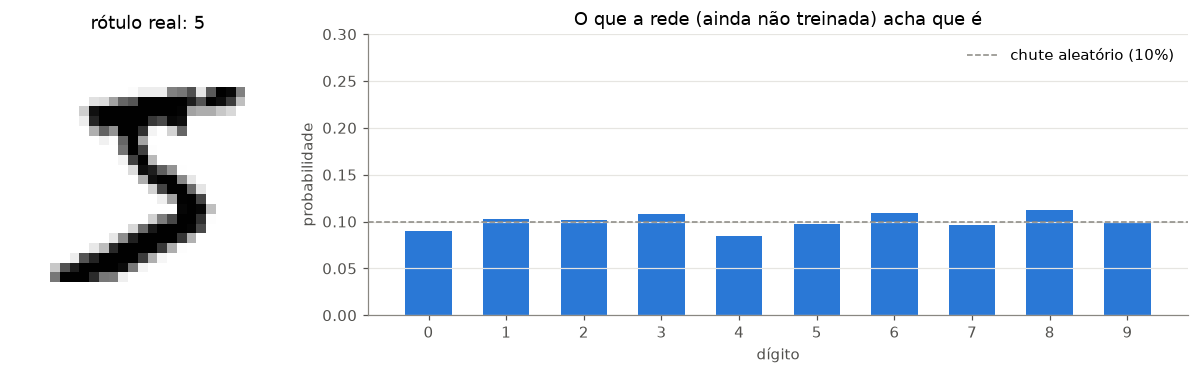

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), width_ratios=[1, 3])
axes[0].imshow(lote[0, 0], cmap="gray_r")
axes[0].set_title(f"rótulo real: {rotulos[0].item()}")
axes[0].axis("off")
axes[1].bar(range(10), probs[0].detach(), color=AZUL, width=0.6)
axes[1].axhline(0.1, color=CINZA, ls="--", lw=1, label="chute aleatório (10%)")
axes[1].set(xticks=range(10), xlabel="dígito", ylabel="probabilidade", ylim=(0, 0.3),
            title="O que a rede (ainda não treinada) acha que é")
axes[1].legend(frameon=False)
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Com os pesos ainda **aleatórios**, a rede dá ~10% para cada dígito: ela é uma função bem definida, mas
inútil. Ensinar a rede a ajustar esses 101.770 parâmetros é o assunto da próxima aula.

## Por que precisamos de funções de ativação?

E se tirássemos a ReLU? Duas camadas lineares seguidas são:

$$W_2(W_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \underbrace{(W_2W_1)}_{W'}\mathbf{x} + \underbrace{(W_2\mathbf{b}_1 + \mathbf{b}_2)}_{\mathbf{b}'}$$

Ou seja, **colapsam em uma única camada linear**. Não importa quantas camadas lineares você empilhe: o
resultado é sempre equivalente a uma só, e uma camada linear só desenha fronteiras retilíneas. Conferindo:

In [46]:
linear1, linear2 = nn.Linear(784, 128), nn.Linear(128, 10)

W_colapsado = linear2.weight @ linear1.weight                    # (10, 128) @ (128, 784) = (10, 784)
b_colapsado = linear2.weight @ linear1.bias + linear2.bias

duas_camadas = linear2(linear1(lote.flatten(1)))
uma_camada = lote.flatten(1) @ W_colapsado.T + b_colapsado

print(f"W' tem formato {tuple(W_colapsado.shape)}: uma única camada 784 p/ 10")
print(f"Duas camadas sem ativação == uma camada? {torch.allclose(duas_camadas, uma_camada, atol=1e-5)}")

W' tem formato (10, 784): uma única camada 784 p/ 10
Duas camadas sem ativação == uma camada? True


A **função de ativação** quebra essa linearidade. Entre cada camada, ela permite a **não-linearidade** do espaço, e é isso que
permite à rede aprender relações complexas. As mais comuns:

| Função | Fórmula | Saída | Uso |
|---|---|---|---|
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | padrão nas camadas escondidas: simples e rápida |
| **Sigmoide** | $\frac{1}{1 + e^{-z}}$ | $(0, 1)$ | saída de classificação binária (probabilidade) |
| **Tanh** | $\frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$ | $(-1, 1)$ | como a sigmoide, mas centrada no zero |

Abaixo, as funções e suas **derivadas** (inclinações). As derivadas vão ser essenciais na próxima aula,
porque é por elas que a rede aprende. Aqui usamos o próprio PyTorch para calculá-las (`backward()`, que
veremos em detalhe na aula 2).

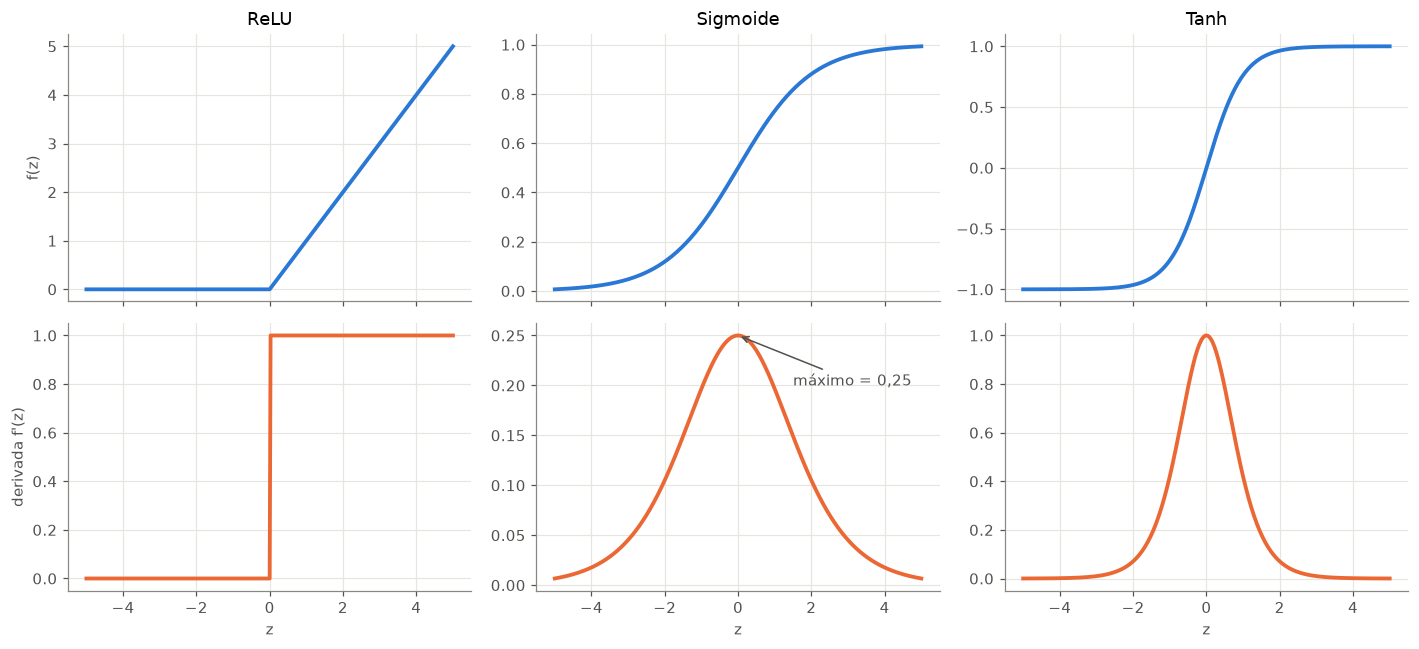

In [16]:
z = torch.linspace(-5, 5, 401, requires_grad=True)
ativacoes = {"ReLU": torch.relu, "Sigmoide": torch.sigmoid, "Tanh": torch.tanh}

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for j, (nome, f) in enumerate(ativacoes.items()):
    z.grad = None
    saida = f(z)
    saida.sum().backward()                     # derivada de cada ponto em relação a z
    axes[0, j].plot(z.detach(), saida.detach(), color=AZUL, lw=2.5)
    axes[0, j].set_title(nome)
    axes[1, j].plot(z.detach(), z.grad, color=LARANJA, lw=2.5)
    axes[1, j].set_xlabel("z")
axes[0, 0].set_ylabel("f(z)")
axes[1, 0].set_ylabel("derivada f'(z)")
axes[1, 1].annotate("máximo = 0,25", xy=(0, 0.25), xytext=(1.5, 0.2), color=TINTA,
                    arrowprops={"arrowstyle": "->", "color": TINTA})
plt.tight_layout()
plt.show()

### Um aviso para o futuro: o gradiente que desaparece

Repare que a derivada da sigmoide é **no máximo 0,25**. Na próxima aula veremos que, para treinar, as derivadas
de cada camada são **multiplicadas** umas pelas outras (regra da cadeia). Com 10 camadas de sigmoide, o sinal
que chega às primeiras camadas pode ser multiplicado por até $0{,}25^{10}$, menos de um milionésimo. As
primeiras camadas praticamente param de aprender: é o problema do **gradiente que desaparece**
(*vanishing gradient*). A derivada da ReLU é 1 para entradas positivas, por isso ela virou o padrão.

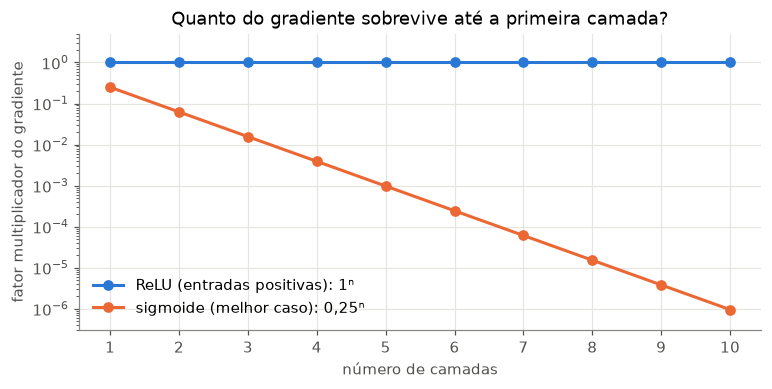

In [47]:
camadas = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(camadas, np.ones(len(camadas)), color=AZUL, lw=2, marker="o", label="ReLU (entradas positivas): 1ⁿ")
ax.plot(camadas, 0.25 ** camadas, color=LARANJA, lw=2, marker="o", label="sigmoide (melhor caso): 0,25ⁿ")
ax.set(yscale="log", xlabel="número de camadas", ylabel="fator multiplicador do gradiente", xticks=camadas,
       ylim=(3e-7, 5), title="Quanto do gradiente sobrevive até a primeira camada?")
ax.legend(frameon=False, loc="lower left")
plt.show()

## O Teorema da Aproximação Universal

> Uma rede com **uma única camada escondida** e uma ativação não linear consegue aproximar **qualquer função
> contínua** (em um intervalo limitado) tão bem quanto se queira, desde que tenha neurônios suficientes.

Não vamos demonstrar o teorema mas sim  ver ele funcionando. Ajustamos $\sin(x)$ com redes
$1 \to n \to 1$ com ReLU, para $n$ = 2, 4, 16 e 128 neurônios.

Cada neurônio ReLU contribui com uma dobra (um pedaço de reta). Com poucos neurônios a aproximação é grosseira, contudo com muitos neuronios, as dobras ficam tão pequenas que a curva parece suave.

*Como* a rede encontra os pesos certos (o `treina` abaixo) é o assunto das aulas 2 e 3. Por enquanto, trate como uma caixa-preta.

In [48]:
x_sen = torch.linspace(-2 * np.pi, 2 * np.pi, 400).unsqueeze(1)   # (400, 1)
y_sen = torch.sin(x_sen)

def treina(rede, x, y, passos=4000):
    """ajusta os pesos da rede para que rede(x) ≈ y."""
    otimizador = torch.optim.Adam(rede.parameters(), lr=0.01)
    for _ in range(passos):
        otimizador.zero_grad()
        perda = ((rede(x) - y) ** 2).mean()
        perda.backward()
        otimizador.step()
    return perda.item()

redes_sen = {}
for n_neuronios in [2, 4, 16, 128]:
    torch.manual_seed(0)
    rede = nn.Sequential(nn.Linear(1, n_neuronios), nn.ReLU(), nn.Linear(n_neuronios, 1))
    erro = treina(rede, x_sen, y_sen)
    redes_sen[n_neuronios] = rede
    print(f"{n_neuronios:>4} neurônios: erro quadrático médio = {erro:.4f}")

   2 neurônios: erro quadrático médio = 0.3893
   4 neurônios: erro quadrático médio = 0.1409
  16 neurônios: erro quadrático médio = 0.0033
 128 neurônios: erro quadrático médio = 0.0016


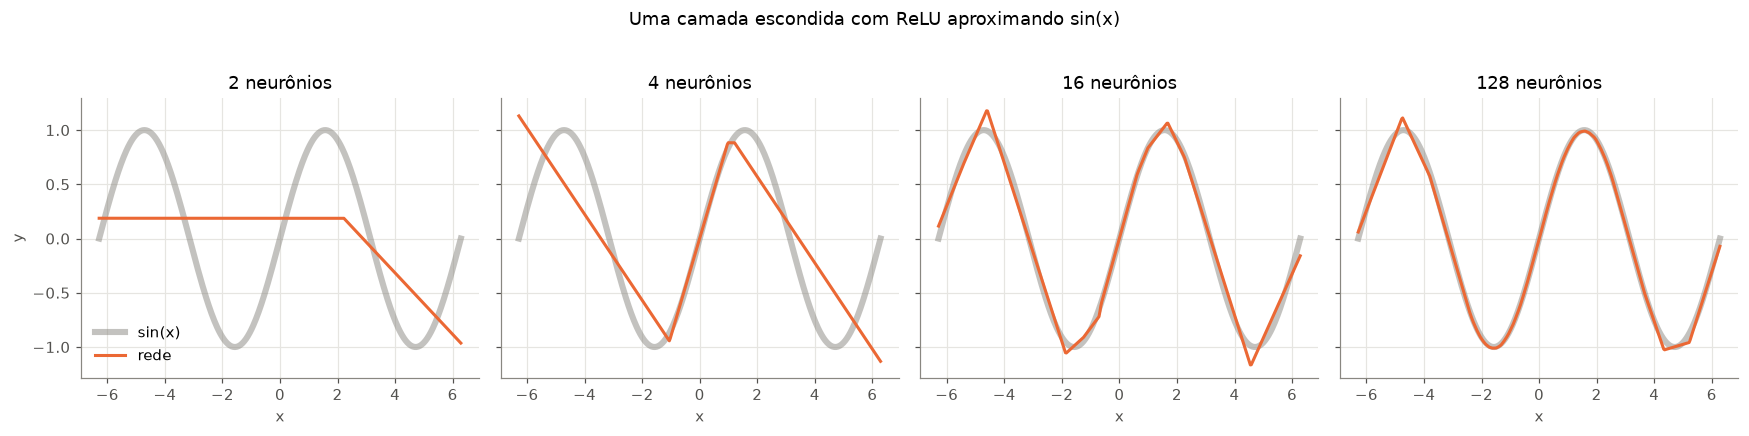

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, (n_neuronios, rede) in zip(axes, redes_sen.items()):
    with torch.no_grad():
        ax.plot(x_sen, y_sen, color=CINZA, lw=4, alpha=0.5, label="sin(x)")
        ax.plot(x_sen, rede(x_sen), color=LARANJA, lw=2, label="rede")
    ax.set(title=f"{n_neuronios} neurônios", xlabel="x")
axes[0].set_ylabel("y")
axes[0].legend(frameon=False, loc="lower left")
plt.suptitle("Uma camada escondida com ReLU aproximando sin(x)", y=1.03)
plt.tight_layout()
plt.show()

### De onde vêm as "dobras"?

A saída da rede é a soma das contribuições de cada neurônio escondido:
$\hat{y} = \sum_i w_{2,i} \cdot \text{ReLU}(w_{1,i}\,x + b_{1,i}) + b_2$. Cada termo é uma "rampa" que começa
em um ponto diferente. Olhando a rede de 4 neurônios:

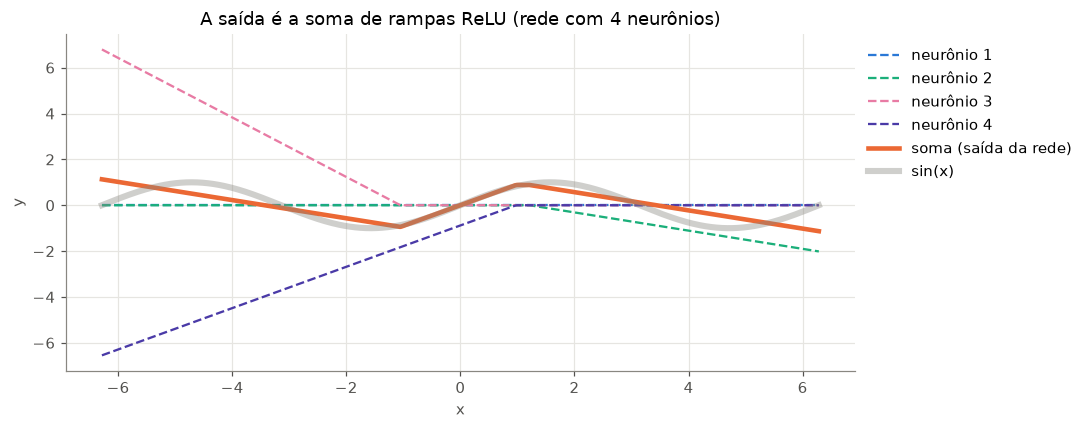

Neurônios que nunca ativam neste intervalo: [1]


In [20]:
rede4 = redes_sen[4]
with torch.no_grad():
    h = torch.relu(rede4[0](x_sen))                 # (400, 4): saída de cada neurônio escondido
    contribuicoes = h * rede4[2].weight[0]          # cada neurônio multiplicado pelo seu peso de saída
    soma = contribuicoes.sum(dim=1) + rede4[2].bias

fig, ax = plt.subplots(figsize=(10, 4))
cores = [AZUL, VERDE, "#e87ba4", "#4a3aa7"]
for i in range(4):
    ax.plot(x_sen, contribuicoes[:, i], color=cores[i], lw=1.5, ls="--", label=f"neurônio {i + 1}")
ax.plot(x_sen, soma, color=LARANJA, lw=3, label="soma (saída da rede)")
ax.plot(x_sen, y_sen, color=CINZA, lw=4, alpha=0.4, label="sin(x)")
ax.set(xlabel="x", ylabel="y", title="A saída é a soma de rampas ReLU (rede com 4 neurônios)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

mortos = [i + 1 for i in range(4) if h[:, i].max() == 0]
print(f"Neurônios que nunca ativam neste intervalo: {mortos if mortos else 'nenhum'}")

Cada neurônio ativo contribui com uma rampa que liga em um ponto diferente de $x$, e a soma das rampas desenha
a curva. Se algum neurônio ficou **zerado em todo o intervalo**, ele é um **neurônio morto** (*dead ReLU*): a
entrada dele é sempre negativa, a ReLU sempre devolve zero e ele não ajuda em nada. Por isso a rede de 2
neurônios acima consegue fazer só uma dobra. Neurônios mortos são um efeito colateral comum da ReLU; ter
neurônios de sobra ajuda.

### O grande porém

O teorema garante que **existe** um conjunto de pesos que aproxima a função. Ele **não** diz:

- quantos neurônios são necessários (pode ser um número enorme);
- **como encontrar** esses pesos;
- se a rede vai funcionar bem em dados que ela nunca viu.

Essa distância entre "existe uma solução" e "conseguimos encontrá-la" é exatamente o que motiva o
**treinamento**, o tema da próxima aula.

## 8. Discussão

- Uma rede neural é uma **função**: entradas → multiplicações de matrizes + ativações → saídas.
- Um **neurônio** é uma soma ponderada mais um viés; uma **camada** é $W\mathbf{x} + \mathbf{b}$; um **MLP**
  são camadas empilhadas com ativações entre elas.
- Sem ativações, qualquer número de camadas **colapsa em uma só**. As ativações dão o poder não linear.
- A ReLU é o padrão nas camadas escondidas; a sigmoide sofre de **gradiente que desaparece** em redes profundas.
- Com neurônios suficientes, uma camada escondida aproxima qualquer função contínua, mas **achar os pesos**
  é outra história.

### Exercícios

1. Mude os pesos `W1` da seção 4 para que os dois neurônios escondidos fiquem negativos antes da ReLU. Qual
   é a saída da rede? Por quê?
2. Troque `nn.ReLU()` por `nn.Tanh()` nas redes que aproximam $\sin(x)$. As curvas ficam diferentes?
3. Aproxime outra função, como $|x|$ ou $x^2$, com 4 neurônios. Quantas "dobras" você precisa para $|x|$?
4. Quantos parâmetros tem um MLP 784 → 256 → 128 → 10? Confira sua conta com `sum(p.numel() for p in modelo.parameters())`.